<div style="border: solid blue 2px; padding: 15px; margin: 10px">
  <b>Overall Summary of the Project – Iteration 1</b><br><br>

  Hi Kemi, I’m <b>Victor Camargo</b> (<a href="https://hub.tripleten.com/u/e9cc9c11" target="_blank">TripleTen Hub profile</a>). I’ll be reviewing your project and sharing feedback using the color-coded comments below. Thanks for submitting your work!<br><br>

  <b>Nice work on:</b><br>
  ✔️ Data preprocessing (date conversion, rounding calls, creating monthly aggregates)<br>
  ✔️ Revenue calculation with plan-specific limits and overage charges<br>
  ✔️ Visualizations for calls, messages, internet, and revenue comparisons<br>
  ✔️ Hypothesis formulation and correct use of t-tests<br><br>

  <b>Suggestions for improvement (not blockers):</b><br>
  🟡 Ensure your printed conclusions match the hypothesis test outcomes (especially for NY-NJ region comparison)<br>
  🟡 Add consistent plots for internet over-usage analysis to match calls and messages<br>
  🟡 Refine the final conclusion wording for accuracy and clarity<br><br>

  <hr>

  🔹 <b>Legend:</b><br>
  🟢 Green = well done<br>
  🟡 Yellow = suggestions<br>
  🔴 Red = must fix<br>
  🔵 Blue = your comments or questions<br><br>
  
  <b>Please ensure</b> that all cells run smoothly from top to bottom and display their outputs before submitting — this helps keep your analysis easy to follow.  
  <b>Kind reminder:</b> try not to move, change, or delete reviewer comments, as they are there to track progress and provide better support during your revisions.<br><br>

  <b>Overall, this project is approved. Great work, Kemi!</b><br>
  <b>Feel free to reach out if you need help in Questions channel.</b><br>
</div>


# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

[We've provided you with some commentary to guide your thinking as you complete this project. However, make sure to remove all the bracketed comments before submitting your project.]

[Before you dive into analyzing your data, explain for yourself the purpose of the project and actions you plan to take.]

[Please bear in mind that studying, amending, and analyzing data is an iterative process. It is normal to return to previous steps and correct/expand them to allow for further steps.]

## Initialization

In [1]:
# Loading all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Load data

In [2]:
# Load the data files into different DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


## Prepare the data

[The data for this project is split into several tables. Explore each one to get an initial understanding of the data. Do necessary corrections to each table if necessary.]

## Plans

In [3]:
# Print the general/summary information about the plans' DataFrame
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Print a sample of data for plans
plans.head()






,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

"""
The above shows the comparison between the two prepaid plans - surf and ultimate, comparing the messages (i.e the free text), 
the MB of data, cost and  minutes per month were analysed so also the cost per extra GB of data, cost per extra text mess
age and cost per extra minute for the two plans were compared. In all the colums, there is complete information for both plans, no missing value. 
The amount  per month, usd_per_gb are in whole number _ integer, so also the mb_per_month, messages_included
' mb_per_month_included, and minutes_included are in whole numeber. 
The plan_name is correctly stored as string _ object. The usd_per_message and usd_per_minute are in decimals.
The mb_per_month_included is in megabytes which need to be converted to gigabytes. The calls would also be rounded up to minutes in the call dataframe analysis.
"""


## Fix data

[Fix obvious issues with the data given the initial observations.]

In [5]:


plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024
print(plans['gb_per_month_included'])


''' The megaline is in megabytes, there is need to chage to gigabytes which was done in the above analysis'''

0    15.0
1    30.0
Name: gb_per_month_included, dtype: float64


' The megaline is in megabytes, there is need to chage to gigabytes which was done in the above analysis'

## Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [6]:
"""Usage Efficiency 
- Plan utilization rate: Percentage of included minutes/messages/data actually used
- Overage frequency: How often users exceed their plan limits"""

'Usage Efficiency \n- Plan utilization rate: Percentage of included minutes/messages/data actually used\n- Overage frequency: How often users exceed their plan limits'

## Users

In [7]:
users.info

# Print the general/summary information about the users' DataFrame



<bound method DataFrame.info of      user_id first_name   last_name  age  \
0       1000   Anamaria       Bauer   45   
1       1001     Mickey   Wilkerson   28   
2       1002     Carlee     Hoffman   36   
3       1003   Reynaldo     Jenkins   52   
4       1004    Leonila    Thompson   40   
..       ...        ...         ...  ...   
495     1495      Fidel      Sharpe   67   
496     1496      Ariel    Shepherd   49   
497     1497      Donte     Barrera   49   
498     1498       Scot  Williamson   51   
499     1499      Shena     Dickson   37   

                                          city    reg_date      plan  \
0        Atlanta-Sandy Springs-Roswell, GA MSA  2018-12-24  ultimate   
1              Seattle-Tacoma-Bellevue, WA MSA  2018-08-13      surf   
2         Las Vegas-Henderson-Paradise, NV MSA  2018-10-21      surf   
3                                Tulsa, OK MSA  2018-01-28      surf   
4              Seattle-Tacoma-Bellevue, WA MSA  2018-05-23      surf   
..     

In [8]:
print(users.head())
# Print a sample of data for users



   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


""" 
The above shows the first five data of the plans. The user_id which is the unique identifier, identified with their first and last names, the ages which ranges from 28 to 52 years, the city per user_id, the date inwhihc they registered for the plan and they are all still active because the churn_date indicates NaN. This shows that age is a vitial factor in the choice of plan  Most customers are on surf plan
"""
[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

### Fix Data

[Fix obvious issues with the data given the initial observations.]

In [9]:
users.isnull().sum()

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

In [10]:
""" the above shows there is no missing value for the user_id, first_name, last_name, age, city,
reg_date, and plan , but the churn_date has missing valuses which means 466 are still active"""

' the above shows there is no missing value for the user_id, first_name, last_name, age, city,\nreg_date, and plan , but the churn_date has missing valuses which means 466 are still active'

In [11]:
users.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [12]:
""" this analysis shows the number of rows ( customers to be 500 and there are no duplicated rows, which simply means there are customers who have churned, this would be analysed below"""

' this analysis shows the number of rows ( customers to be 500 and there are no duplicated rows, which simply means there are customers who have churned, this would be analysed below'

In [13]:
churned_customers = users[users['churn_date'].notna()]
print(f"Number of churned customers: {len(churned_customers)}")

Number of churned customers: 34


### Enrich Data

[Add additional factors to the data if you believe they might be useful.]

In [14]:
""" it is important to consider the ages of the users that are not active, and their plans"""

' it is important to consider the ages of the users that are not active, and their plans'

## Calls

In [15]:
calls.info()

# Print the general/summary information about the calls' DataFrame



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [16]:
print(calls.head())
# Print a sample of data for calls



         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [17]:
""" 
The user_id 1000 made several calls, the date format is YYYY-MM-DD farmat.
From the megaline analysis, the calls are to be rounded up to minutes which would be done below  The call_date needs to be changed to date format instead of it being in Object.
This would be done below"""

' \nThe user_id 1000 made several calls, the date format is YYYY-MM-DD farmat.\nFrom the megaline analysis, the calls are to be rounded up to minutes which would be done below  The call_date needs to be changed to date format instead of it being in Object.\nThis would be done below'

In [18]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

In [19]:
calls['duration'] = np.ceil(calls['duration'])

In [20]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enrich data

[Add additional factors to the data if you believe they might be useful.]

## Messages

In [21]:
messages.info()
# Print the general/summary information about the messages' DataFrame



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [22]:
print(messages.head())

# Print a sample of data for messages



         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [23]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

### Enrich data

[Add additional factors to the data if you believe they might be useful.]

## Internet

In [24]:

internet.info()
# Print the general/summary information about the internet DataFrame



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [25]:
print(internet.head())
# Print a sample of data for the internet traffic



         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


In [26]:
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


In [28]:
internet['month'] = internet['session_date'].dt.month
internet

,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12
...,...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06,10
104821,1499_216,1499,2018-12-30,304.72,12
104822,1499_217,1499,2018-09-22,292.75,9
104823,1499_218,1499,2018-12-07,0.00,12


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

 <div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Good work preparing the data. You converted the date columns to datetime, rounded call durations to minutes, and created a month column for the internet dataset. These preprocessing steps follow the project requirements and set up the analysis correctly.
</div>


### Fix data

[Fix obvious issues with the data given the initial observations.]

### Enrich data

[Add additional factors to the data if you believe they might be useful.]

## Study plan conditions

[It is critical to understand how the plans work, how users are charged based on their plan subscription. So, we suggest printing out the plan information to view their conditions once again.]

In [30]:
# # Print out the plan conditions and make sure they are clear for you

# """Surf Plan
# Monthly charge: $20

# Included allowances:
# - 500 monthly minutes
# - 50 text messages  
# - 15 GB of data

# Overage charges (after exceeding limits):
# - 1 minute: 3 cents
# - 1 text message: 3 cents
# - 1 GB of data: $10

# Ultimate Plan
# Monthly charge: $70

# Included allowances:
# - 3000 monthly minutes
# - 1000 text messages
# - 30 GB of data

# Overage charges (after exceeding limits):
# - 1 minute: 1 cent
# - 1 text message: 1 cent
# - 1 GB of data: $7

# Important Billing Rules
# Megaline has specific rounding rules:

# For calls: Each individual call is rounded UP to the nearest minute (even 1 second = 1 minute)
# For data: Individual sessions aren't rounded, but the total monthly usage is rounded UP to the nearest GB (e.g., 1025 MB = 2 GB charged)"""
plans


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Aggregate data per user

[Now, as the data is clean, aggregate data per user per period in order to have just one record per user per period. It should ease the further analysis a lot.]

In [31]:
# Calculate the number of calls made by each user per month. Save the result.
# Convert call_date to datetime 
calls['call_date'] = pd.to_datetime(calls['call_date'])

# Extract year-month for grouping
calls['month'] = calls['call_date'].dt.month

monthly_calls = calls.groupby(['user_id','month']).size().reset_index()
monthly_calls

,user_id,month,0
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64
...,...,...,...
2253,1498,12,39
2254,1499,9,41
2255,1499,10,53
2256,1499,11,45


In [32]:
# Calculate the amount of minutes spent by each user per month. Save the result.


monthly_minutes = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
monthly_minutes['total_calls'] = monthly_calls[0]
monthly_minutes

,user_id,month,duration,total_calls
0,1000,12,124.0,16
1,1001,8,182.0,27
2,1001,9,315.0,49
3,1001,10,393.0,65
4,1001,11,426.0,64
...,...,...,...,...
2253,1498,12,339.0,39
2254,1499,9,346.0,41
2255,1499,10,385.0,53
2256,1499,11,308.0,45


In [33]:
messages['month'] = messages['message_date'].dt.month
monthly_messages = messages.groupby(['user_id', 'month']).size().reset_index()
monthly_messages = monthly_messages.rename(columns={0:'num_messages'})
monthly_messages
# Calculate the number of messages sent by each user per month. Save the result.



,user_id,month,num_messages
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


In [34]:
# internet.info()


volume_internet = internet.groupby(['user_id','month'])['mb_used'].sum().reset_index()
volume_internet['gb_used'] = np.ceil(volume_internet['mb_used']/1024)
volume_internet


      


# Calculate the volume of internet traffic used by each user per month. Save the result.



,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0
...,...,...,...,...
2272,1498,12,23137.69,23.0
2273,1499,9,12984.76,13.0
2274,1499,10,19492.43,20.0
2275,1499,11,16813.83,17.0


<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Well done aggregating the monthly data. You correctly calculated the number of calls, total minutes, messages, and internet volume per user per month. Converting megabytes to gigabytes with rounding also matches the project requirements.
</div>


[Put the aggregate data together into one DataFrame so that one record in it would represent what an unique user consumed in a given month.]

In [35]:
merged_data = monthly_minutes.merge(monthly_messages, on=['user_id', 'month'], how='outer')
merged_data = merged_data.merge(volume_internet, on=['user_id', 'month'], how='outer')
merged_data = merged_data.merge(users, on=['user_id'], how='inner')
merged_data

,user_id,month,duration,total_calls,num_messages,mb_used,gb_used,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,12,124.0,16.0,11.0,1901.47,2.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,8,182.0,27.0,30.0,6919.15,7.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1001,9,315.0,49.0,44.0,13314.82,14.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
3,1001,10,393.0,65.0,53.0,22330.49,22.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
4,1001,11,426.0,64.0,36.0,18504.30,19.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1204,12,NaN,NaN,78.0,36730.05,36.0,Sherly,Levy,44,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-08-20,ultimate,NaN
2289,1349,10,NaN,NaN,76.0,13093.55,13.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaN
2290,1349,11,NaN,NaN,72.0,17128.26,17.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaN
2291,1349,12,NaN,NaN,61.0,13039.91,13.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaN


In [36]:
# Add the plan information

merged_data= merged_data.merge(plans, left_on= 'plan', right_on='plan_name', how='left')




In [37]:
merged_data

,user_id,month,duration,total_calls,num_messages,mb_used,gb_used,first_name,last_name,age,...,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,12,124.0,16.0,11.0,1901.47,2.0,Anamaria,Bauer,45,...,NaN,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
1,1001,8,182.0,27.0,30.0,6919.15,7.0,Mickey,Wilkerson,28,...,NaN,50,15360,500,20,10,0.03,0.03,surf,15.0
2,1001,9,315.0,49.0,44.0,13314.82,14.0,Mickey,Wilkerson,28,...,NaN,50,15360,500,20,10,0.03,0.03,surf,15.0
3,1001,10,393.0,65.0,53.0,22330.49,22.0,Mickey,Wilkerson,28,...,NaN,50,15360,500,20,10,0.03,0.03,surf,15.0
4,1001,11,426.0,64.0,36.0,18504.30,19.0,Mickey,Wilkerson,28,...,NaN,50,15360,500,20,10,0.03,0.03,surf,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1204,12,NaN,NaN,78.0,36730.05,36.0,Sherly,Levy,44,...,NaN,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
2289,1349,10,NaN,NaN,76.0,13093.55,13.0,Florentina,Diaz,69,...,NaN,50,15360,500,20,10,0.03,0.03,surf,15.0
2290,1349,11,NaN,NaN,72.0,17128.26,17.0,Florentina,Diaz,69,...,NaN,50,15360,500,20,10,0.03,0.03,surf,15.0
2291,1349,12,NaN,NaN,61.0,13039.91,13.0,Florentina,Diaz,69,...,NaN,50,15360,500,20,10,0.03,0.03,surf,15.0


<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Good work merging the datasets. You combined calls, messages, internet, users, and plans into a single DataFrame with consistent keys. This creates the correct structure for calculating monthly revenue and analyzing user behavior.
</div>


[Calculate the monthly revenue from each user (subtract the free package limit from the total number of calls, text messages, and data; multiply the result by the calling plan value; add the monthly charge depending on the calling plan). N.B. This might not be as trivial as just a couple of lines given the plan conditions! So, it's okay to spend some time on it.]

In [38]:
plans


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


In [39]:

# Calculate the monthly revenue for each user
def monthly_revenue_calc(row):
    # print(row)
    if row['plan'] == 'surf':
        usd_monthly_pay = 20
        minutes_limit = 500
        messages_limit = 50
        data_limit_gb = 15
        usd_per_gb = 10
        usd_per_min = 0.03
        usd_per_message= 0.03
        actual_data_gb = row['gb_used']
        actual_messages = row['num_messages']
        actual_minutes  = row['duration']

        
    else:
        usd_monthly_pay = 70
        minutes_limit = 3000
        messages_limit = 1000
        data_limit_gb = 30
        usd_per_gb = 7
        usd_per_min = 0.01
        usd_per_message= 0.01
        actual_data_gb  = row ['gb_used']
        actual_messages = row['num_messages']
        actual_minutes = row['duration']
                
    minutes_overage = max(0, actual_minutes - minutes_limit)*usd_per_min
    messages_overage = max(0, actual_messages - messages_limit)*usd_per_message
    data_overage = max(0, actual_data_gb - data_limit_gb)*usd_per_gb

    result = usd_monthly_pay + minutes_overage + messages_overage + data_overage

    return result

merged_data['monthly_revenue'] = merged_data.apply(monthly_revenue_calc,axis=1)
#merged_data

In [40]:
merged_data['monthly_revenue'].describe()

count    2293.000000
mean       64.351147
std        46.624945
min        20.000000
25%        23.480000
50%        70.000000
75%        70.000000
max       590.370000
Name: monthly_revenue, dtype: float64

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Nice work implementing the monthly revenue calculation. You correctly set up plan-specific limits, applied overage charges only when usage exceeded the allowance, and added the fixed monthly fee. The function is applied row-wise and produces a consistent revenue column for further analysis.
</div>


## Study user behaviour

[Calculate some useful descriptive statistics for the aggregated and merged data, which typically reveal an overall picture captured by the data. Draw useful plots to help the understanding. Given that the main task is to compare the plans and decide on which one is more profitable, the statistics and the plots should be calculated on a per-plan basis.]

[There are relevant hints in the comments for Calls but they are not provided for Messages and Internet though the principle of statistical study is the same for them as for Calls.]

### Calls

<function matplotlib.pyplot.show(close=None, block=None)>

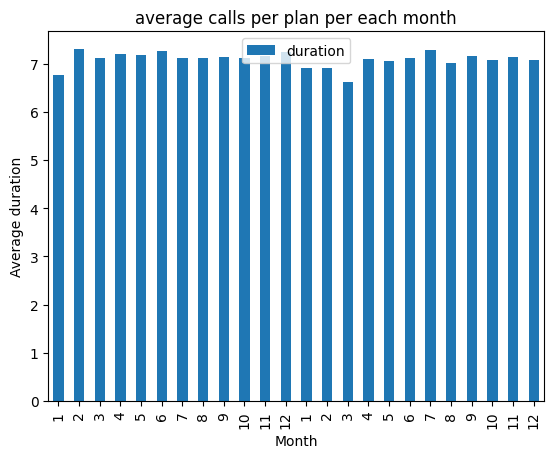

In [41]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plat to visualize it.


calls['month'] = calls['call_date'].dt.month
calls_with_plans = calls.merge(users[['user_id', 'plan']], on='user_id')
avg_duration_by_plan_month = calls_with_plans.groupby(['plan', 'month'])['duration'].mean().reset_index()


avg_duration_by_plan_month.plot(kind='bar', x='month', y='duration', legend = 'plan', title = 'average calls per plan per each month', xlabel= 'Month', ylabel= 'Average duration')
plt.show




In [42]:
avg_duration_by_plan_month


,plan,month,duration
0,surf,1,6.766667
1,surf,2,7.303279
2,surf,3,7.106742
3,surf,4,7.191899
4,surf,5,7.173700
5,surf,6,7.251863
6,surf,7,7.124836
7,surf,8,7.124718
8,surf,9,7.128537
9,surf,10,7.120604


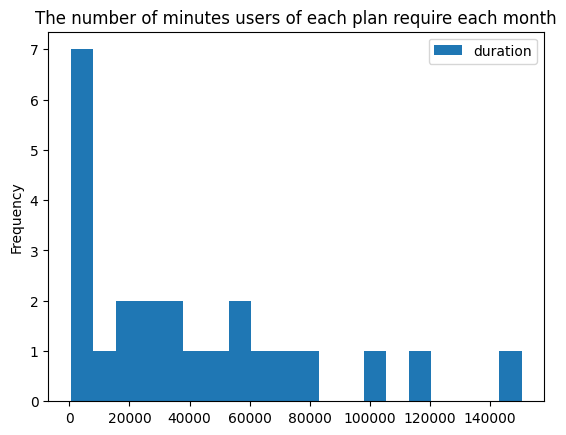

In [44]:

# Compare the number of minutes users of each plan require each month. Plot a histogram.


calls['month'] = calls['call_date'].dt.month
calls_with_plans = calls.merge(users[['user_id', 'plan']], on='user_id')
plan_month  = calls_with_plans.groupby(['plan', 'month'])['duration'].sum().reset_index()


plan_month.plot(kind='hist', bins=20, x='month', y='duration', title = 'The number of minutes users of each plan require each month')
    
plt.show()




[Calculate the mean and the variable of the call duration to reason on whether users on the different plans have different behaviours for their calls.]

In [45]:
# Merge calls with users to get plan information for each calls_with_plans 
calls_with_plans = calls.merge(users[['user_id', 'plan']], on='user_id')
# Group by plan and get call duration statistics
plan_groups = calls_with_plans.groupby('plan')['duration']
# Calculate mean for each plan
mean_by_plan = plan_groups.mean()

mean_by_plan
# Calculate the mean and the variance of the monthly call duration



plan
surf        7.168307
ultimate    7.100044
Name: duration, dtype: float64

In [46]:
#variance for each plan
variance_by_plan = plan_groups.var()

variance_by_plan


plan
surf        35.502268
ultimate    35.332282
Name: duration, dtype: float64

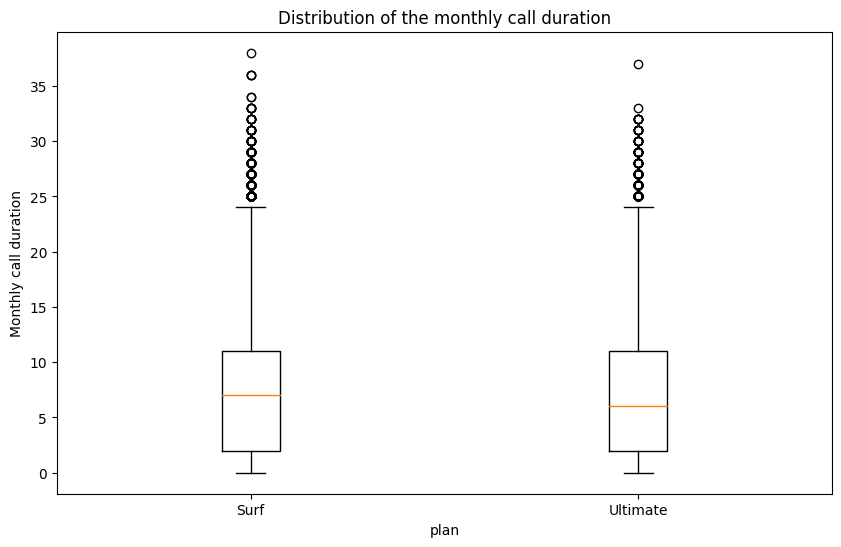

In [48]:
# Plot a boxplot to visualize the distribution of the monthly call duration
plt.figure(figsize=(10, 6))

surf_duration = calls_with_plans[calls_with_plans['plan'] == 'surf']['duration']
ultimate_duration = calls_with_plans[calls_with_plans['plan'] == 'ultimate']['duration']
plt.boxplot([surf_duration, ultimate_duration], labels=['Surf', 'Ultimate'])
plt.title('Distribution of the monthly call duration')
plt.ylabel('Monthly call duration')
plt.xlabel('plan')


plt.show()


In [50]:
""" From the above box plot, the surf has higer median line than the ultimate plan, there is no much visible difference in the whiskers.
the outlier of the surf is more than than of the ultimate plan. the surf plan users makes longer calls    """

' From the above box plot, the surf has higer median line than the ultimate plan, there is no much visible difference in the whiskers.\nthe outlier of the surf is more than than of the ultimate plan. the surf plan users makes longer calls    '

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Good analysis and visualization of call durations. You compared average call duration by plan and month, plotted histograms to show overall usage patterns, and added a boxplot for distribution comparison. The interpretation of Surf users making slightly longer calls with more outliers is clear and consistent with the plots.
</div>


[Formulate conclusions on how the users behave in terms of calling. Is their behaviour different between the plans?]

### Messages

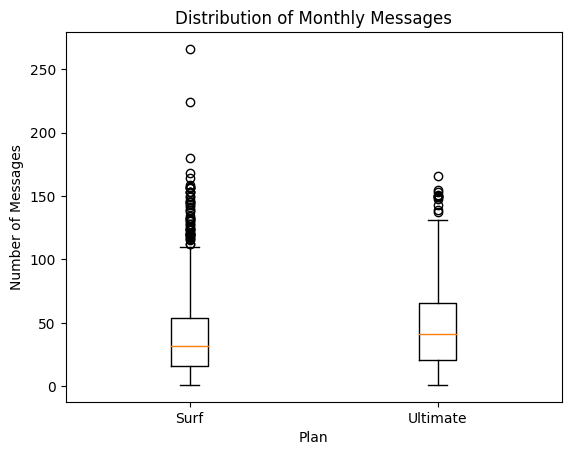

In [52]:
# Compare the number of messages users of each plan tend to send each month
messages_with_plans = messages.merge(users[['user_id', 'plan']], on='user_id')
monthly_messages_by_plan = messages_with_plans.groupby(['user_id', 'month', 'plan']).size().reset_index(name='message_count')
surf_messages = monthly_messages_by_plan [monthly_messages_by_plan ['plan'] == 'surf']['message_count']
ultimate_messages = monthly_messages_by_plan [monthly_messages_by_plan ['plan'] == 'ultimate']['message_count']
plt.boxplot([surf_messages, ultimate_messages], labels=['Surf', 'Ultimate'])
plt.title('Distribution of Monthly Messages')
plt.ylabel('Number of Messages')
plt.xlabel('Plan')
plt.show()

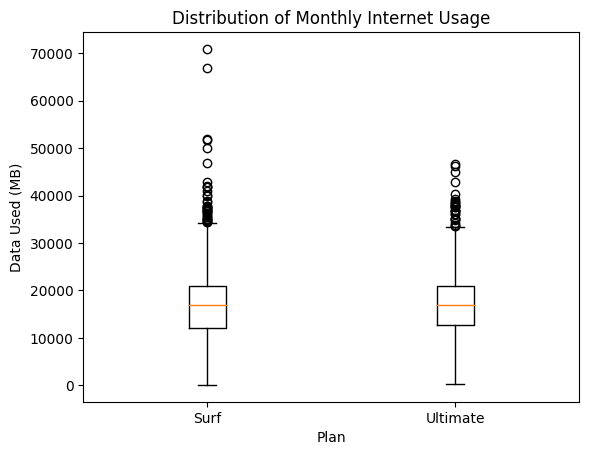

In [53]:
# Compare the amount of internet traffic consumed by users per plan

internet_with_plans = internet.merge(users[['user_id', 'plan']], on='user_id')
# Group by user, month, and plan to get total MB used per month
monthly_internet_by_plan = internet_with_plans.groupby(['user_id', 'month', 'plan'])['mb_used'].sum().reset_index()
surf_internet = monthly_internet_by_plan[monthly_internet_by_plan['plan'] == 'surf']['mb_used']
ultimate_internet = monthly_internet_by_plan[monthly_internet_by_plan['plan'] == 'ultimate']['mb_used']
plt.boxplot([surf_internet, ultimate_internet], labels=['Surf', 'Ultimate'])
plt.title('Distribution of Monthly Internet Usage')
plt.ylabel('Data Used (MB)')
plt.xlabel('Plan')
plt.show()

In [54]:
""" I will examine the message limit against the over messaging"""
message_limits = {
    'surf': 50,
    'ultimate': 1000
}

merged_data['message_limit'] = merged_data['plan'].map(message_limits)
merged_data_overage = (merged_data ['num_messages'] - merged_data['message_limit'])


In [55]:
merged_data_overage.describe()

count    1806.000000
mean     -315.088040
std       442.832675
min      -999.000000
25%      -931.000000
50%       -33.000000
75%        -8.000000
max       216.000000
dtype: float64

In [56]:
""" The above analyses shows that the on the average  , customers use less than their message limit, just a small percentage exceed their limits"""

' The above analyses shows that the on the average  , customers use less than their message limit, just a small percentage exceed their limits'

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Clear comparison of messages and internet usage across plans. You merged correctly with plan information, grouped by user and month, and visualized distributions with boxplots. The additional check against message limits shows that most customers stay under their allowance, which strengthens the interpretation.
</div>


[Formulate conclusions on how the users behave in terms of messaging. Is their behaviour different between the plans?]

### Internet

In [57]:
# internet over usage for surf
#merge volume _internet with users
volume_with_plans = volume_internet.merge(users[['user_id','plan']], on='user_id', how ='left')
#merge with plans to get plan details
volume_with_plan_details = volume_with_plans.merge(plans, left_on='plan', right_on ='plan_name',how ='left')
volume_with_plan_details



,user_id,month,mb_used,gb_used,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,12,1901.47,2.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
1,1001,8,6919.15,7.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
2,1001,9,13314.82,14.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
3,1001,10,22330.49,22.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
4,1001,11,18504.30,19.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2272,1498,12,23137.69,23.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
2273,1499,9,12984.76,13.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
2274,1499,10,19492.43,20.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
2275,1499,11,16813.83,17.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0


<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Good work merging the internet usage with users and plan details. This creates the correct dataset to evaluate over-usage per plan.
</div>

<div class="alert alert-warning">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Suggestion: you analyzed over-usage correctly, but you did not include the same type of plots (boxplots or histograms) as you did for calls and messages. Adding those plots here would give a consistent visual comparison across all features.
</div>


[Formulate conclusions on how the users tend to consume the internet traffic? Is their behaviour different between the plans?]

## Revenue

[Likewise you have studied the user behaviour, statistically describe the revenue between the plans.]

In [58]:
"""Comparisim of the revenue for the two plans """
surf_revenue = merged_data[merged_data['plan'] == 'surf']['monthly_revenue']
surf_revenue.describe()

count    1573.000000
mean       60.706408
std        55.388042
min        20.000000
25%        20.000000
50%        40.360000
75%        80.360000
max       590.370000
Name: monthly_revenue, dtype: float64

In [60]:
ultimate_revenue = merged_data[merged_data['plan']=='ultimate']['monthly_revenue'] 
ultimate_revenue.describe()

count    720.000000
mean      72.313889
std       11.395108
min       70.000000
25%       70.000000
50%       70.000000
75%       70.000000
max      182.000000
Name: monthly_revenue, dtype: float64

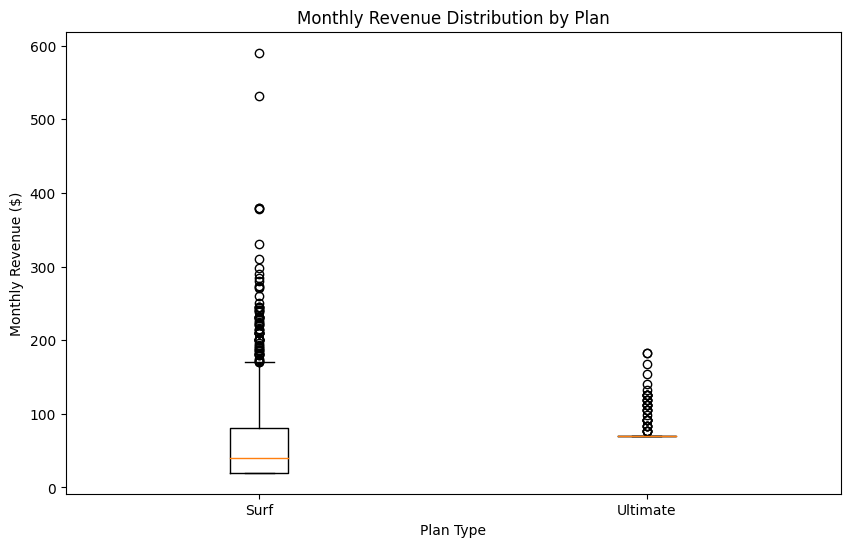

In [61]:
plt.figure(figsize=(10, 6))
surf_revenue = merged_data[merged_data['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = merged_data[merged_data['plan'] == 'ultimate']['monthly_revenue']
plt.boxplot([surf_revenue, ultimate_revenue], labels=['Surf', 'Ultimate'])
plt.title('Monthly Revenue Distribution by Plan')
plt.xlabel('Plan Type')
plt.ylabel('Monthly Revenue ($)')
plt.show()

[Formulate conclusions about how the revenue differs between the plans.]

In [62]:
"""The ultimate plan has a median value higher than surf plan. The ultimate plan has higher revenue and it is consistent compare to the surf plan. The ultimate plan has less variation """

'The ultimate plan has a median value higher than surf plan. The ultimate plan has higher revenue and it is consistent compare to the surf plan. The ultimate plan has less variation '

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Well done comparing revenues by plan. You summarized the descriptive statistics and visualized the distributions with a boxplot, then clearly concluded that Ultimate brings higher and more consistent revenue than Surf.
</div>


## Test statistical hypotheses

[Test the hypothesis that the average revenue from users of the Ultimate and Surf calling plans differs.]

[Formulate the null and the alternative hypotheses, choose the statistical test, decide on the alpha value.]

In [63]:

# Null hypothesis (H0): There is no difference in average revenue between Ultimate and Surf plans
# Alternative hypothesis (H1): There is a difference in average revenue between Ultimate and Surf plans
# Using independent t-test because:
# - We're comparing means of two independent groups
# - We want to test if there's a significant difference
alpha = 0.05 # write your code here

results = stats.ttest_ind(ultimate_revenue, surf_revenue) # write your code here

print('p-value: ', results.pvalue) # write your code here)

if results.pvalue<alpha: # write your code here):
    print('We reject the null hypothesis')
    print('There is a statistically significant difference in average revenue between Ultimate and Surf plans')
else:
    print("We can't reject the null hypothesis")
    print('There is NO statistically significant difference in average revenue between the plans')



p-value:  2.862674510698644e-08
We reject the null hypothesis
There is a statistically significant difference in average revenue between Ultimate and Surf plans


[Test the hypothesis that the average revenue from users in the NY-NJ area is different from that of the users from the other regions.]

[Formulate the null and the alternative hypotheses, choose the statistical test, decide on the alpha value.]

In [64]:
# Test the hypotheses
# Null hypothesis (H0): There is no difference in average revenue from users in the NY-NJ area from the users and the other regions
# Alternative hypothesis (H1): There is a difference in average revenue  from users in the NY-NJ area from the users and the other regions
# Using independent t-test because:
# - We're comparing means of two independent groups
# - We want to test if there's a significant difference
merged_data['region'] = merged_data['city'].apply(
    lambda x: 'NY-NJ' if x in ['New York-Newark-Jersey City, NY-NJ-PA MSA'] else 'Other'
)

print(merged_data['region'].value_counts())



Other    1916
NY-NJ     377
Name: region, dtype: int64


In [65]:
ny_nj_revenue = merged_data[merged_data['region'] == 'NY-NJ']['monthly_revenue']
other_revenue = merged_data[merged_data['region'] == 'Other']['monthly_revenue']
ny_nj_avg = ny_nj_revenue.mean()
other_avg = other_revenue.mean()

print(f'NY-NJ average revenue: ${ny_nj_avg:.2f}')
print(f'Other regions average revenue: ${other_avg:.2f}')

NY-NJ average revenue: $59.92
Other regions average revenue: $65.22


In [66]:
alpha = 0.05 

results = stats.ttest_ind(ny_nj_revenue,other_revenue)


print(f'p-value: {results.pvalue:.4f}')

if results.pvalue<alpha: 
    print('We reject the null hypothesis')
    print('There is no difference in average revenue from users in the NY-NJ area from the users and the other regions')
else:
    print("We can't reject the null hypothesis")
    print('There is NO statistically significant difference in average revenue between the regions')


p-value: 0.0436
We reject the null hypothesis
There is no difference in average revenue from users in the NY-NJ area from the users and the other regions


<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Good job formulating and testing the hypotheses. You stated clear null and alternative hypotheses, applied the independent t-test correctly for plan comparison and regional comparison, and interpreted the p-values with respect to the chosen alpha level.
</div>

<div class="alert alert-warning">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Suggestion: In the second hypothesis conclusion, the printed message is inconsistent — it says "we reject the null" but then states "there is no difference." Please adjust the output text so that it matches the result of the test.
</div>


## General conclusion

[List your important conclusions in this final section, make sure they cover all those important decisions (assumptions) that you've made and that led you to the way you processed and analyzed the data.]

The analysis evaluated the user behavior based on the two plans. The Ultimate plan is more profitable because of its consistency y, and that there is a difference in average revenue between users in the NY-NJ area and users from other regions. These findings can help the company make informed decisions for marketing purposes

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Clear final conclusion summarizing the results of the analysis. You highlighted the profitability of the Ultimate plan and addressed the regional revenue comparison, linking the findings back to business decisions.
</div>

<div class="alert alert-warning">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Suggestion: refine the wording for clarity and consistency. For example, the hypothesis test results indicated no statistically significant difference between NY-NJ and other regions, but your conclusion states there is a difference. Align the conclusion with the statistical test outcome.
</div>
